In [23]:
from sympy import *
from sympy.physics.mechanics import *
init_vprinting

<function sympy.physics.vector.printing.init_vprinting(**kwargs)>

In [24]:
## Declare the symbols
m1,m2,l1,l2,g,t = symbols("m1,m2,l1,l2,g,t")
theta1,theta2=dynamicsymbols("theta1,theta2")

## Position
x1=l1*sin(theta1)
y1=-l1*cos(theta1)

x2=l1*sin(theta1) + l2*sin(theta2)
y2=-l1*cos(theta1) - l2*cos(theta2)

## Derivatives
x1_dot=diff(x1,t)
#x1_ddot=diff(x1,t,2)
y1_dot=diff(y1,t)
#y1_ddot=diff(y1,t,2)

x2_dot=diff(x2,t)
#x2_ddot=diff(x2,t,2)
y2_dot=diff(y2,t)
#y2_ddot=diff(y2,t,2)

theta1_dot=diff(theta1,t)
theta1_ddot=diff(theta1,t,2)

theta2_dot=diff(theta2,t)
theta2_ddot=diff(theta2,t,2)

In [25]:
### Define the Kinetic and potential energies
T= 0.5*m1*(x1_dot**2  + y1_dot**2) + 0.5*m2*(x2_dot**2 + y2_dot**2)
V= m1*g*y1 + m2*g*y2
L=T-V

## Solve the E-L equation
eq1=diff(diff(L,theta1_dot),t) - diff(L,theta1)
eq2=diff(diff(L,theta2_dot),t) - diff(L,theta2)

sols=solve([eq1,eq2],[theta1_ddot,theta2_ddot])

f=Matrix([theta1,sols[theta1_ddot],theta2,sols[theta2_ddot]])
f_simp=simplify(f)
x_mat=Matrix([theta1,theta1_dot,theta2,theta2_dot])
Eq(diff(x_mat,t),f_simp)

Eq(Matrix([
[     Derivative(theta1(t), t)],
[Derivative(theta1(t), (t, 2))],
[     Derivative(theta2(t), t)],
[Derivative(theta2(t), (t, 2))]]), Matrix([
[                                                                                                                                                                                                                                                                                                                                                                                                             theta1(t)],
[                                                                                                            (-0.5*g*m1*sin(theta1(t)) - 0.25*g*m2*sin(theta1(t) - 2*theta2(t)) - 0.25*g*m2*sin(theta1(t)) - 0.25*l1*m2*sin(2*theta1(t) - 2*theta2(t))*Derivative(theta1(t), t)**2 - 0.5*l2*m2*sin(theta1(t) - theta2(t))*Derivative(theta2(t), t)**2)/(l1*(0.5*m1 - 0.25*m2*cos(2*theta1(t) - 2*theta2(t)) + 0.25*m2))],
[                        

In [26]:
h=f_simp.subs({theta1:"theta1",theta1_dot:"theta1_dot",theta2:"theta2",theta2_dot:"theta2_dot"})
for i in range(4):
    print(f"f[{i}]={h[i]}")

f[0]=theta1
f[1]=(-0.5*g*m1*sin(theta1) - 0.25*g*m2*sin(theta1) - 0.25*g*m2*sin(theta1 - 2*theta2) - 0.25*l1*m2*theta1_dot**2*sin(2*theta1 - 2*theta2) - 0.5*l2*m2*theta2_dot**2*sin(theta1 - theta2))/(l1*(0.5*m1 - 0.25*m2*cos(2*theta1 - 2*theta2) + 0.25*m2))
f[2]=theta2
f[3]=(-0.25*g*m1*sin(theta2) + 0.25*g*m1*sin(2*theta1 - theta2) - 0.25*g*m2*sin(theta2) + 0.25*g*m2*sin(2*theta1 - theta2) + 0.5*l1*m1*theta1_dot**2*sin(theta1 - theta2) + 0.5*l1*m2*theta1_dot**2*sin(theta1 - theta2) + 0.25*l2*m2*theta2_dot**2*sin(2*theta1 - 2*theta2))/(l2*(0.5*m1 - 0.25*m2*cos(2*theta1 - 2*theta2) + 0.25*m2))


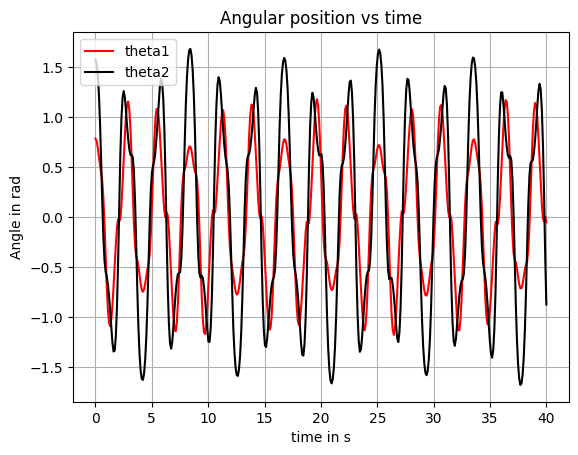

In [27]:
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import numpy as np

## Declare the constants
m1=1
m2=1
l1=1
l2=1
g=9.81
ic=np.array([np.deg2rad(45),0,np.deg2rad(90),0])
def double_pendulum_ode(t,r):
    theta1=r[0]
    theta1_dot=r[1]
    theta2=r[2]
    theta2_dot=r[3]
    return (
        theta1_dot,
        (-0.5*g*m1*np.sin(theta1) - 0.25*g*m2*np.sin(theta1) - 0.25*g*m2*np.sin(theta1 - 2*theta2) - 0.25*l1*m2*theta1_dot**2*np.sin(2*theta1 - 2*theta2) - 0.5*l2*m2*theta2_dot**2*np.sin(theta1 - theta2))/(l1*(0.5*m1 - 0.25*m2*np.cos(2*theta1 - 2*theta2) + 0.25*m2)),
        theta2_dot,
        (-0.25*g*m1*np.sin(theta2) + 0.25*g*m1*np.sin(2*theta1 - theta2) - 0.25*g*m2*np.sin(theta2) + 0.25*g*m2*np.sin(2*theta1 - theta2) + 0.5*l1*m1*theta1_dot**2*np.sin(theta1 - theta2) + 0.5*l1*m2*theta1_dot**2*np.sin(theta1 - theta2) + 0.25*l2*m2*theta2_dot**2*np.sin(2*theta1 - 2*theta2))/(l2*(0.5*m1 - 0.25*m2*np.cos(2*theta1 - 2*theta2) + 0.25*m2))
    )

soln=solve_ivp(double_pendulum_ode,[0,40],ic,t_eval=np.linspace(0,40,400))

thetaa=soln.y[0]
thetab=soln.y[2]
time=soln.t

plt.plot(time,thetaa,label="theta1",color="r")
plt.plot(time,thetab,label="theta2",color="k")
plt.xlabel("time in s")
plt.ylabel("Angle in rad")
plt.GridSpec(10,10)
plt.legend()
plt.grid()
plt.title("Angular position vs time")
plt.show()


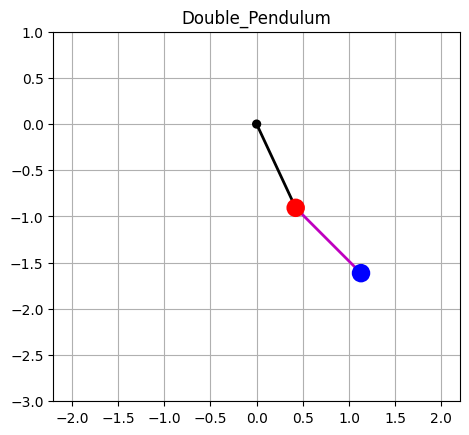

<Figure size 640x480 with 0 Axes>

In [28]:
## create Figure
import numpy as np
import matplotlib.pyplot as plt

figure=plt.figure()
ax=figure.add_subplot(aspect="equal")
ax.set_title("Double_Pendulum")
ax.grid()
ax.set_xlim(-2.2,2.2)
ax.set_ylim(-3,1)

def m1_position(ang1):
    return l1*np.sin(ang1),-l1*np.cos(ang1)

def m2_position(ang1,ang2):
    x2=l1*sin(ang1) + l2*sin(ang2)
    y2=-l1*cos(ang1) - l2*cos(ang2)
    return (x2,y2)

x1,y1=m1_position(np.deg2rad(25))
x2,y2=m2_position(np.deg2rad(25),np.deg2rad(45))

ax.plot([0,x1],[0,y1],color="k",linewidth=2)
ax.plot([x1,x2],[y1,y2],color="m",linewidth=2)
ax.add_patch(plt.Circle([0,0],radius=0.05,facecolor='k',zorder=2))
ax.add_patch(plt.Circle([x1,y1],radius=0.1,facecolor='r',zorder=2))
ax.add_patch(plt.Circle([x2,y2],radius=0.1,facecolor='b',zorder=3))
plt.show()
plt.savefig("Simple_pendulum_initial_position.png")


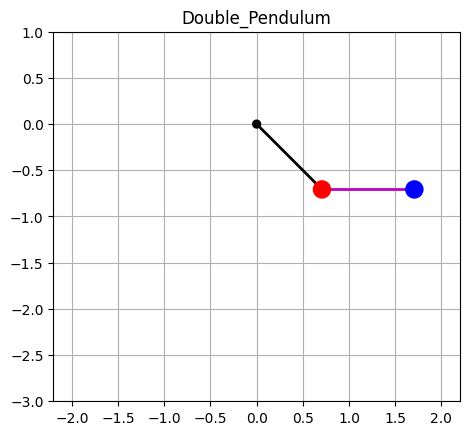

In [31]:
## create Animation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
##
thetaa=soln.y[0]
thetab=soln.y[2]
time=soln.t

fig= plt.figure()
ax=fig.add_subplot(aspect="equal")
ax.set_title("Double_Pendulum")
ax.grid()
ax.set_xlim(-2.2,2.2)
ax.set_ylim(-3,1)


s1,=ax.plot([0,x1],[0,y1],color="k",linewidth=2)
s2,=ax.plot([x1,x2],[y1,y2],color="m",linewidth=2)
ax.add_patch(plt.Circle([0,0],radius=0.05,facecolor='k',zorder=2))
p_m1=ax.add_patch(plt.Circle([x1,y1],radius=0.1,facecolor='r',zorder=2))
p_m2=ax.add_patch(plt.Circle([x2,y2],radius=0.1,facecolor='b',zorder=3))

def animate(i):
    x1,y1=m1_position(thetaa[i])
    x2,y2=m2_position(thetaa[i],thetab[i])
    s1.set_data([0,x1],[0,y1])
    s2.set_data([x1,x2],[y1,y2])
    p_m1.set_center((x1,y1))
    p_m2.set_center((x2,y2))

anim=animation.FuncAnimation(fig,animate,frames=len(time))
ffmpeg_writer=animation.FFMpegWriter(fps=30)
anim.save("Double_Pendulum_Simulation.mp4",writer=ffmpeg_writer)
anim.save("Double_pendulum_gif.gif",writer=ffmpeg_writer)
